<a href="https://colab.research.google.com/github/alyosha-bar/API-Cost-Predictor/blob/main/API_Cost_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Data Manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Visualization & App
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Utilities
import datetime

In [ ]:
import joblib

In [ ]:
# Data Generation
def generate_api_data(days=365):
    dates = pd.date_range(start="2025-01-01", periods=days)

    # 1. Baseline Trend (gradual growth)
    trend = np.linspace(50, 200, days)

    # 2. Weekly Seasonality (Weekends are 40% quieter)
    # 0=Monday, 6=Sunday
    seasonality = np.array([1.0 if d.weekday() < 5 else 0.6 for d in dates])

    # 3. Random Noise & Spikes (Marketing events/bugs)
    noise = np.random.normal(0, 5, days)
    spikes = np.random.choice([0, 50, 100], size=days, p=[0.95, 0.03, 0.02])

    # Combine to get Daily Cost
    daily_cost = (trend * seasonality) + noise + spikes

    return pd.DataFrame({'date': dates, 'cost': daily_cost.clip(min=10)})

df = generate_api_data()

# df.to_csv("api_costs.csv", index=False)

df.head()

# Data Preparation

# Standardise cost values between 0 - 1
scaler = MinMaxScaler(feature_range=(0, 1))

costs_reshaped = df['cost'].values.reshape(-1, 1)
scaled_costs = scaler.fit_transform(costs_reshaped)

joblib.dump(scaler, 'cost_scaler.pkl')

['cost_scaler.pkl']

In [ ]:
# Define a dataset class
class APICostDataset(Dataset):
  def __init__(self, data, window_size=7):
    self.data = torch.FloatTensor(data)
    self.window_size = window_size

  def __len__(self):
    return len(self.data) - self.window_size

  def __getitem__(self, idx):
    # extract 7 days for X, and he 8th for Y
    x = self.data[idx : idx + self.window_size]
    y = self.data[idx + self.window_size]
    return x, y


In [ ]:
class CostPredictor(nn.Module):
  def __init__(self, input_dim=1, hidden_dim=32, num_layers=4):
    super(CostPredictor, self).__init__()

    # batch_first = True --> means input shape is (Batch, Seq, Feature)
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.linear = nn.Linear(hidden_dim, 1)

  def forward(self, x):
    # lstm out: (Batch, Seq, Hidden)
    lstm_out, (h_n, c_n) = self.lstm(x)

    # use the hidden state of the LAST time step (index -1)
    last_time_step = lstm_out[:, -1, :]
    prediction = self.linear(last_time_step)
    return prediction

In [ ]:
# Training Loop
# Window the list --> format (X examples, X days each, X features)
# Use nn.LSTM or nn.GRU followed by a nn.Linear for training
# Loss function --> nn.MSELoss()
# Optimisation --> Adam optimiser

# Split the raw scaled data first
train_size = int(len(scaled_costs) * 0.8)
train_data = scaled_costs[:train_size]
test_data = scaled_costs[train_size:]

# Create TWO dataset objects
train_dataset = APICostDataset(train_data, window_size=7)
test_dataset = APICostDataset(test_data, window_size=7)

# Create TWO loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


model = CostPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Actual training loop
epochs = 80
for epoch in range(epochs):
  model.train()
  total_loss = 0

  for x_batch, y_batch in train_loader:
    optimizer.zero_grad()

    outputs = model(x_batch)

    loss = criterion(outputs, y_batch)

    loss.backward()

    optimizer.step()

    total_loss += loss.item()


  if epoch % 10 == 0:
    print(f'Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f}')

Epoch 0 | Loss: 0.0079
Epoch 10 | Loss: 0.0052
Epoch 20 | Loss: 0.0050
Epoch 30 | Loss: 0.0049
Epoch 40 | Loss: 0.0049
Epoch 50 | Loss: 0.0063
Epoch 60 | Loss: 0.0065
Epoch 70 | Loss: 0.0062


In [ ]:
model.eval()

test_predictions = []
actual_values = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        # 1. Forward pass only
        pred = model(x_test)

        # 2. Store the results (convert back to numpy)
        test_predictions.append(pred.item())
        actual_values.append(y_test.item())

In [ ]:
# Convert lists to numpy arrays and reshape for the scaler
test_predictions = np.array(test_predictions).reshape(-1, 1)
actual_values = np.array(actual_values).reshape(-1, 1)

# Inverse transform
final_preds = scaler.inverse_transform(test_predictions)
final_actuals = scaler.inverse_transform(actual_values)

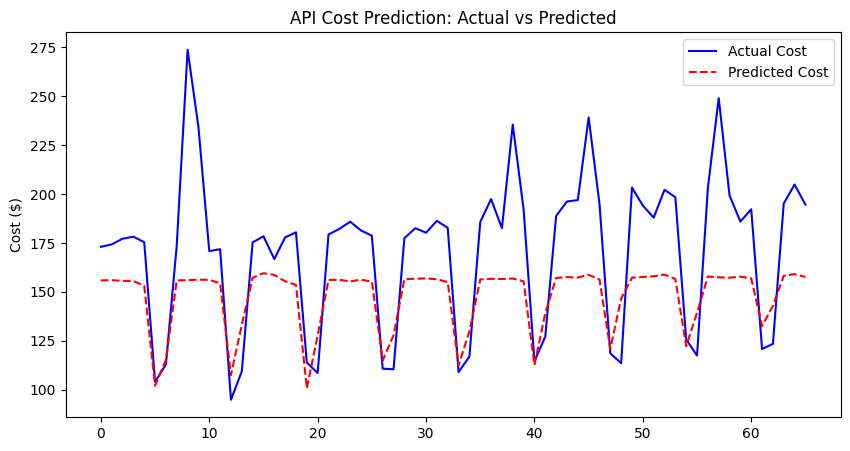

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(final_actuals, label='Actual Cost', color='blue')
plt.plot(final_preds, label='Predicted Cost', color='red', linestyle='--')
plt.title('API Cost Prediction: Actual vs Predicted')
plt.ylabel('Cost ($)')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(final_actuals, final_preds)
print(f"On average, the model is off by: ${mae:.2f}")

On average, the model is off by: $29.02


In [ ]:
# Prediction
# Recursive forecasting --> use Days 1 - 7 to predict day 8
# Then append day 8 to example to predict day 9 ...
# Inverse transform from 0 - 1 values back to $ values

# Save locally or to your mounted Google Drive
MODEL_PATH = "api_cost_model_v1.pth"
torch.save(model.state_dict(), MODEL_PATH)


In [ ]:
# app_utils.py
class ModelPredictor:
    def __init__(self, model_path, scaler_path):
        # 1. Load the Scaler
        self.scaler = joblib.load(scaler_path)

        # 2. Re-initialize the Architecture
        self.model = CostPredictor(input_dim=1, hidden_dim=32, num_layers=4)

        # 3. Load the Weights
        self.model.load_state_dict(torch.load(model_path))
        self.model.eval() # CRITICAL: Set to evaluation mode

    def predict_next_day(self, last_7_days_costs):
      """
      Args:
          last_7_days_costs (list or np.array): Raw dollar amounts for the last 7 days.
      Returns:
          float: Predicted dollar amount for the next day.
      """
      # 1. Preprocess: Reshape and Scale
      # Input must be 2D for the scaler: (7, 1)
      raw_data = np.array(last_7_days_costs).reshape(-1, 1)
      scaled_data = self.scaler.transform(raw_data)

      # 2. Prepare for PyTorch: (Batch, Seq, Feature)
      # We want 1 batch, 7 days, 1 feature (cost) -> Shape: (1, 7, 1)
      input_tensor = torch.FloatTensor(scaled_data).view(1, 7, 1)

      # 3. Predict: Use the model without calculating gradients
      self.model.eval()
      with torch.no_grad():
          prediction_scaled = self.model(input_tensor)

      # 4. Inverse Scale: Convert 0-1 back to Dollars
      # .numpy() converts the tensor, inverse_transform returns a 2D array
      prediction_dollars = self.scaler.inverse_transform(prediction_scaled.numpy())

      # Return as a clean float rounded to 2 decimal places
      return round(float(prediction_dollars[0][0]), 2)

In [ ]:
# Streamlit for now

In [ ]:
# 2. LOAD THE ASSETS
# Ensure these files are in your current folder (or Drive path)
MODEL_PATH = "api_cost_model_v1.pth"
SCALER_PATH = "cost_scaler.pkl"

scaler = joblib.load(SCALER_PATH)
model = CostPredictor(input_dim=1, hidden_dim=32, num_layers=4)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# 3. GENERATE "RECENT" DATA (The Last 7 Days)
# Imagine these are the real costs from Feb 21 - Feb 27
recent_costs = [450.20, 435.10, 442.00, 460.50, 480.00, 310.40, 295.10]
print(f"Input Costs (Last 7 Days): {recent_costs}")

# 4. THE PREDICTION PIPELINE
def get_tomorrow_forecast(data_list):
    # Scale it
    scaled_data = scaler.transform(np.array(data_list).reshape(-1, 1))

    # Reshape for PyTorch: (Batch=1, Seq=7, Feature=1)
    input_tensor = torch.FloatTensor(scaled_data).view(1, 7, 1)

    # Predict
    with torch.no_grad():
        prediction_scaled = model(input_tensor)

    # Inverse Scale back to Dollars
    prediction_dollars = scaler.inverse_transform(prediction_scaled.numpy())
    return prediction_dollars[0][0]

# 5. EXECUTE
tomorrow_cost = get_tomorrow_forecast(recent_costs)

print("-" * 30)
print(f"🚀 PREDICTED COST FOR TOMORROW: ${tomorrow_cost:.2f}")
print("-" * 30)

Input Costs (Last 7 Days): [450.2, 435.1, 442.0, 460.5, 480.0, 310.4, 295.1]
------------------------------
🚀 PREDICTED COST FOR TOMORROW: $160.75
------------------------------
